# 13a — Structural Credit-Risk Baselines: Merton and Black-Cox

The Merton (1974) model's equity-implied asset-value/volatility
calibration and default probability, and the Black-Cox (1976)
first-passage-time default probability — the two classic "structural"
credit-risk models that this chapter's later climate extensions build
on.

**Implementation note:** `pd_merton_model` and `pd_black_cox_model`
aren't available as ready-made implementations elsewhere in this
project, so they were built and verified here as
`quanttoolbox.credit.structural.pd_merton_model`/`pd_black_cox_model`.
Each returns a small bundle of related outputs — asset value, asset
volatility, distance-to-default, and PD for the Merton model;
first-passage PD alongside its intermediate quantities for Black-Cox.

**Reconstruction note:** the three-curve PD-vs-maturity plot in the
first section (three `(sigma_E, mu_A)` scenarios swept over
`tau=0..10`) had unclear axis/legend context to build from directly.
The scenario parameters were inferred from the legend labels and axis
range, and the resulting curves reproduce the expected textbook shape.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from quanttoolbox.credit.structural import pd_merton_model, pd_black_cox_model

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"
color_black  = "#000000"
color_white  = "#ffffff"

colors = [color_blue, color_red, color_green, color_violet]

plt.rcParams["figure.dpi"] = 100


## 1. Merton model: calibrated PD and PD-vs-maturity sensitivity

`E0=3`, `sigma_E=40%`, `D=10`, `mu_A=7%`, `r=5%`, `T=1`, `tau=1`: the
single-point calibrated asset value `A0`, asset volatility `sigma_A`,
distance-to-default `DD`, and PD (in bps). Then, as reconstructed
above, PD swept over `tau=0..10` for 3 `(sigma_E, mu_A)` scenarios.


In [2]:
E0, sigma_E, D, mu_A, r, T, tau = 3, 0.40, 10, 0.07, 0.05, 1, 1

r1 = pd_merton_model(E0, sigma_E, D, mu_A, r, T, tau)
print(f"{r1.a0:10.3f} {100*r1.sigma_a:10.3f} {r1.dd_tau:10.3f} {1e4*r1.pd_tau:10.3f}")
print("(A0, sigma_A %, DD, PD in bps)")


    12.512      9.609      3.012     12.962
(A0, sigma_A %, DD, PD in bps)


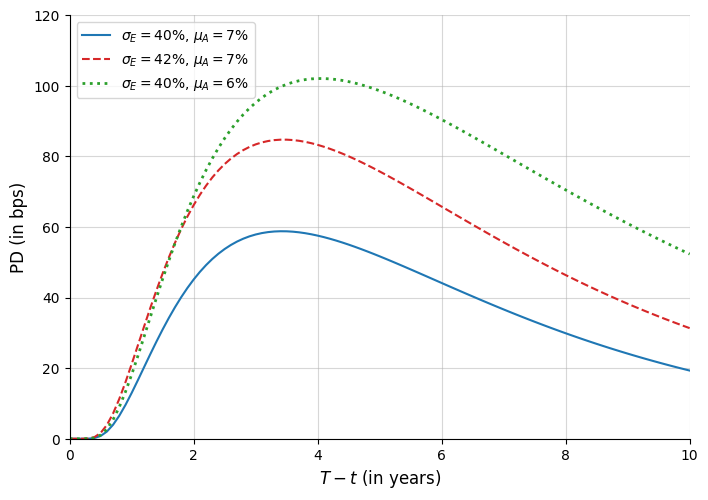

In [3]:
# Three-curve PD-vs-tau plot for the (sigma_E, mu_A) scenarios above
tau_grid = np.arange(0, 10.01, 0.1)
scenarios = [
    (0.40, 0.07, "-", color_blue, r"$\sigma_E = 40\%$, $\mu_A = 7\%$"),
    (0.42, 0.07, "--", color_red, r"$\sigma_E = 42\%$, $\mu_A = 7\%$"),
    (0.40, 0.06, ":", color_green, r"$\sigma_E = 40\%$, $\mu_A = 6\%$"),
]

fig, ax = plt.subplots(figsize=(8, 5.5))
with np.errstate(divide="ignore", invalid="ignore"):
    # tau=0 is a 0/0-or-x/0 boundary case: PD -> 0 as the horizon -> 0
    for sig_e, mu_a_i, style, c, label in scenarios:
        res = pd_merton_model(E0, sig_e, D, mu_a_i, r, T, tau_grid)
        pd_curve = np.nan_to_num(1e4 * res.pd_tau, nan=0.0)
        ax.plot(tau_grid, pd_curve, style, color=c, linewidth=1.5 if style != ":" else 2.0, label=label)

ax.set_xlabel("$T-t$ (in years)", fontsize=12)
ax.set_ylabel("PD (in bps)", fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 10)
ax.set_xticks(range(0, 11, 2))
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
plt.show()


## 2. Merton model: PD vs. asset drift `mu_A`

The Merton model's PD plotted vs. `mu_A` (0-10%) for three scenarios:
`(T-t=1, D=10)`, `(T-t=2, D=10)`, `(T-t=1, D=15)` — with `E0=3`,
`sigma_E=40%`, `r=5%`, `T=1` fixed throughout.


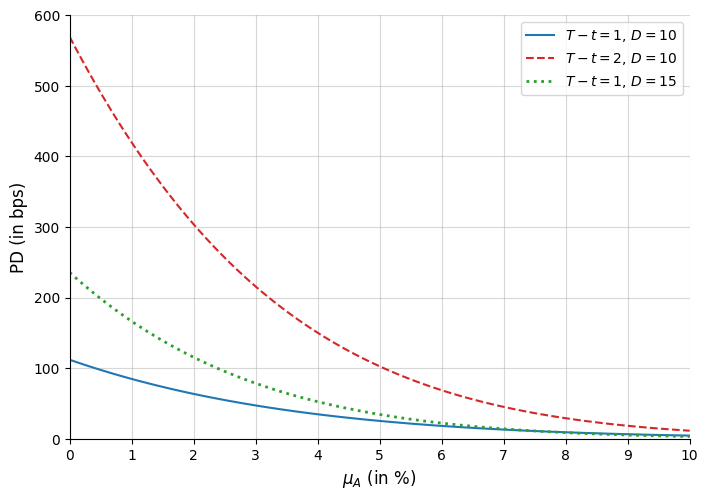

In [4]:
E0, sigma_E, r, T = 3, 0.40, 0.05, 1
mu_A_grid = np.arange(0, 0.1001, 0.001)

y1 = pd_merton_model(E0, sigma_E, 10, mu_A_grid, r, T, 1).pd_tau
y2 = pd_merton_model(E0, sigma_E, 10, mu_A_grid, r, T, 2).pd_tau
y3 = pd_merton_model(E0, sigma_E, 15, mu_A_grid, r, T, 1).pd_tau

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(100 * mu_A_grid, 1e4 * y1, "-", color=color_blue, linewidth=1.5, label="$T-t=1$, $D=10$")
ax.plot(100 * mu_A_grid, 1e4 * y2, "--", color=color_red, linewidth=1.5, label="$T-t=2$, $D=10$")
ax.plot(100 * mu_A_grid, 1e4 * y3, ":", color=color_green, linewidth=2.0, label="$T-t=1$, $D=15$")

ax.set_xlabel(r"$\mu_A$ (in %)", fontsize=12)
ax.set_ylabel("PD (in bps)", fontsize=12)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 10)
ax.set_xticks(range(0, 11, 1))
ax.set_ylim(0, 600)
ax.set_yticks(range(0, 601, 100))
plt.show()


## 3. Black-Cox model: 4-panel first-passage PD sensitivity

The Black-Cox model's first-passage PD swept individually over `t`,
`B` (barrier), `mu_A`, and `sigma_A`, each panel overlaying the base-case
point (`A0=30`, `B=15`, `mu_A=5%`, `sigma_A=20%`, `tau=5`) as a white
circle on the continuous curve.


PD=6.9388%  d1=1.8853  d2=-1.2145  varphi=0.3536


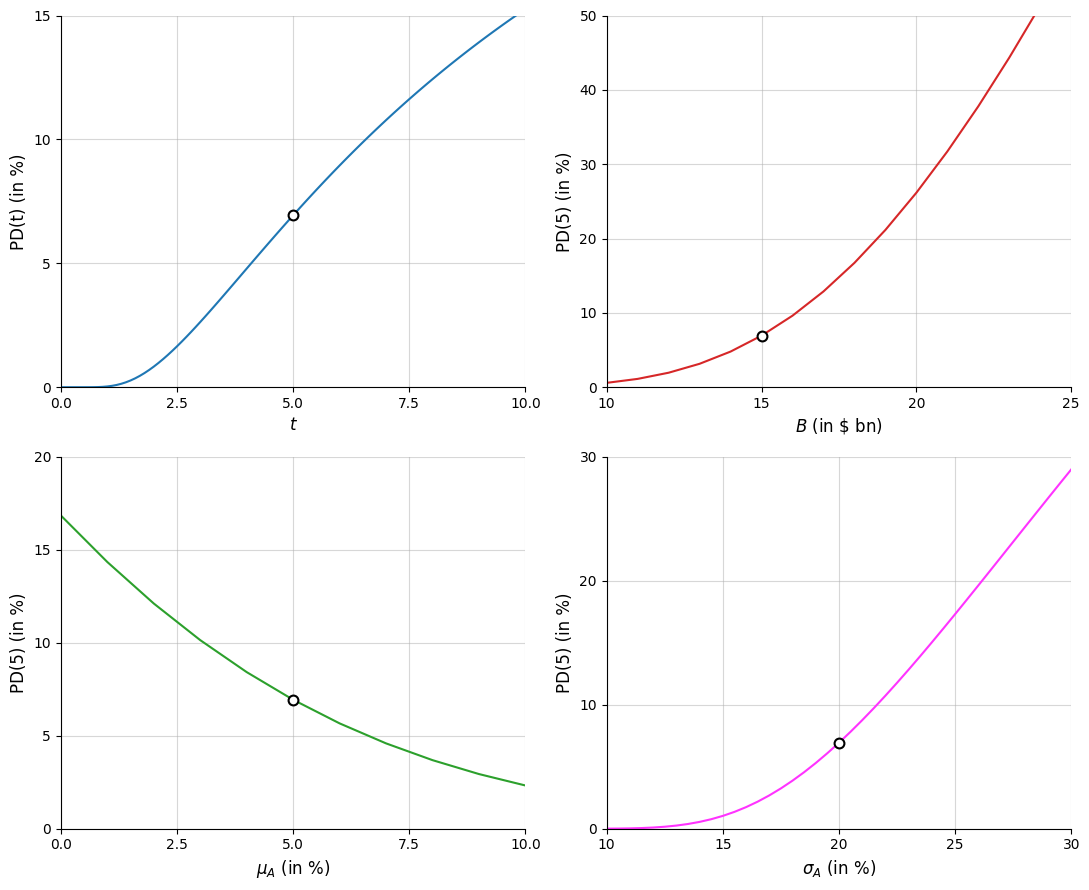

In [5]:
A0, B0, mu_A0, sigma_A0, tau0 = 30, 15, 0.05, 0.20, 5

with np.errstate(divide="ignore", invalid="ignore"):
    # base case
    base = pd_black_cox_model(A0, mu_A0, sigma_A0, B0, tau0)
    x0 = [tau0, B0, 100 * mu_A0, 100 * sigma_A0]
    y0 = base.pd_tau
    print(f"PD={100*y0:.4f}%  d1={base.d1:.4f}  d2={base.d2:.4f}  varphi={base.varphi:.4f}")

    tau_v = np.arange(0, 10.01, 0.1)
    x1, y1 = tau_v, pd_black_cox_model(A0, mu_A0, sigma_A0, B0, tau_v).pd_tau

    B_v = np.arange(10, 25.01, 1)
    x2, y2 = B_v, pd_black_cox_model(A0, mu_A0, sigma_A0, B_v, tau0).pd_tau

    mu_A_v = np.arange(0, 0.1001, 0.01)
    x3, y3 = 100 * mu_A_v, pd_black_cox_model(A0, mu_A_v, sigma_A0, B0, tau0).pd_tau

    sigma_A_v = np.arange(0.10, 0.3001, 0.005)
    x4, y4 = 100 * sigma_A_v, pd_black_cox_model(A0, mu_A0, sigma_A_v, B0, tau0).pd_tau

panels = [
    (x1, y1, "$t$", (0, 10), 2.5, (0, 15), 5, "PD(t) (in %)"),
    (x2, y2, "$B$ (in \$ bn)", (10, 25), 5, (0, 50), 10, "PD(5) (in %)"),
    (x3, y3, r"$\mu_A$ (in %)", (0, 10), 2.5, (0, 20), 5, "PD(5) (in %)"),
    (x4, y4, r"$\sigma_A$ (in %)", (10, 30), 5, (0, 30), 10, "PD(5) (in %)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for i, (ax, (x, y, xlabel, xlim, dx, ylim, dy, ylabel)) in enumerate(zip(axes.flat, panels)):
    y_clean = np.nan_to_num(100 * np.asarray(y), nan=0.0)
    ax.plot(x, y_clean, "-", color=colors[i], linewidth=1.5)
    ax.scatter([x0[i]], [100 * y0], s=50, facecolors=color_white, edgecolors=color_black, linewidths=1.5, zorder=5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1e-9, dx))
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1e-9, dy))

plt.tight_layout()
plt.show()
